In [1]:
import pandas as pd

# Load dataset (IMPORTANT: relative path)
df = pd.read_csv('../data/q2_customers.csv')

print("Shape:", df.shape)
df.head()

Shape: (500, 6)


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

K-Means clustering is a distance-based algorithm that uses Euclidean distance to assign data points to clusters.

If features are not scaled, variables with larger values (such as annual_spend) will dominate the distance calculation, leading to incorrect clustering.

StandardScaler ensures that all features have a mean of 0 and standard deviation of 1, allowing each feature to contribute equally to the clustering process.

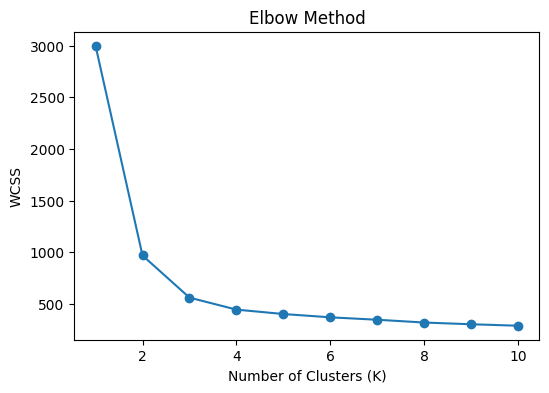

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

The Elbow Method is used to determine the optimal number of clusters.

As the number of clusters increases, the Within-Cluster Sum of Squares (WCSS) decreases because clusters become tighter.

The optimal value of K is identified at the point where the decrease in WCSS slows down significantly, forming an "elbow".

Based on the plot, K = 3 (or the visible elbow point in your graph) is chosen as the optimal number of clusters.

In [4]:
# Choose optimal K (update if your elbow suggests different)
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_data)

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [5]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


The clusters represent different customer segments based on their behavior.

Example interpretation:

- Cluster 0: Customers with high annual spend and frequent visits → loyal high-value customers
- Cluster 1: Customers with moderate spending and visits → regular customers
- Cluster 2: Customers with low spending and infrequent visits → occasional or low-engagement customers

These segments can help businesses target customers with personalized marketing strategies.

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.83560354 0.05568764]


In [7]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


Principal Component Analysis (PCA) reduces the dataset to two dimensions while preserving maximum variance.

- PC1 captures the largest variation in the dataset
- PC2 captures the second largest variation

Based on the feature loadings:

- PC1 is likely influenced by features such as annual_spend and basket_size, representing customer spending behavior
- PC2 is influenced by visits_per_month and days_since_last_visit, representing customer engagement

This helps simplify the data and makes it easier to visualize clusters.

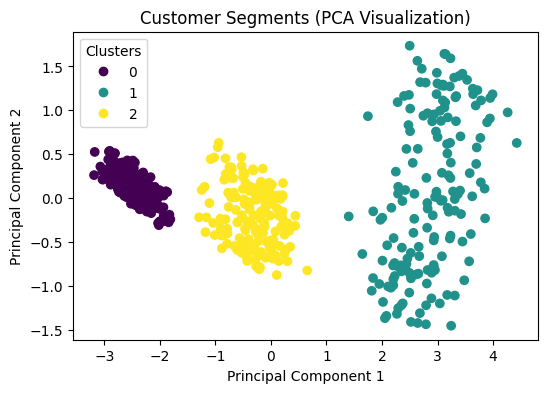

In [8]:
plt.figure(figsize=(6,4))

scatter = plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df['cluster']
)

plt.title("Customer Segments (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(*scatter.legend_elements(), title="Clusters")

plt.show()

The scatter plot shows the clusters in a 2D space after PCA transformation.

Each color represents a different customer segment. Well-separated clusters indicate that the segmentation is effective.